In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

nav = pd.read_csv("/workspaces/bluestock_mf_capstone/data/processed/clean_nav.csv")
tx = pd.read_csv("/workspaces/bluestock_mf_capstone/data/processed/clean_transactions.csv")
perf = pd.read_csv("/workspaces/bluestock_mf_capstone/data/processed/clean_performance.csv")

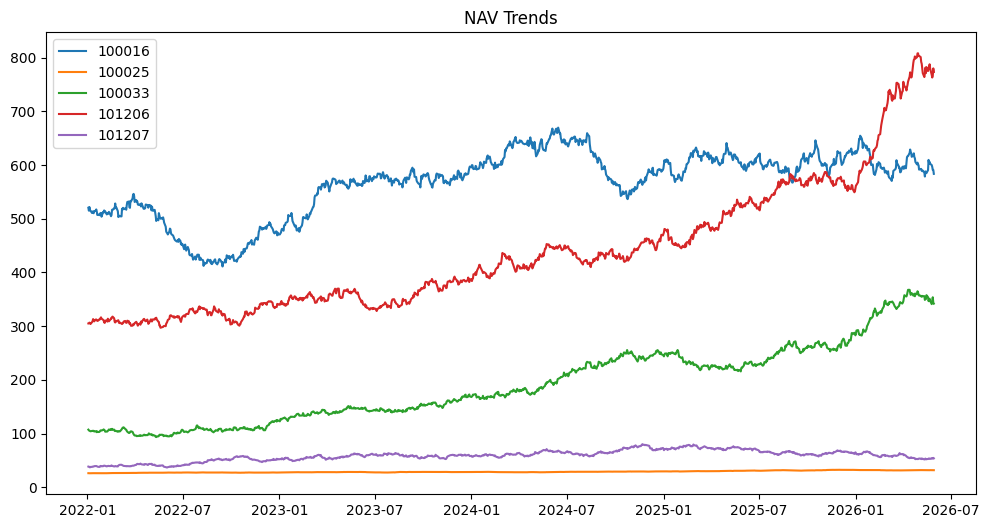

In [3]:
nav["date"] = pd.to_datetime(nav["date"])

sample = nav[nav["amfi_code"].isin(
    nav["amfi_code"].unique()[:5]
)]

plt.figure(figsize=(12,6))

for code in sample["amfi_code"].unique():
    df = sample[sample["amfi_code"] == code]
    plt.plot(df["date"], df["nav"], label=str(code))

plt.legend()
plt.title("NAV Trends")
plt.show()

In [5]:
from pathlib import Path
project_root = None
for parent in [Path.cwd(), *Path.cwd().parents]:
    if (parent / "README.md").exists() and (parent / "data").exists():
        project_root = parent
        break
if project_root is None:
    project_root = Path.cwd()
report_path = project_root / "reports"
report_path.mkdir(parents=True, exist_ok=True)
plt.savefig(report_path / "nav_trend.png")


<Figure size 640x480 with 0 Axes>

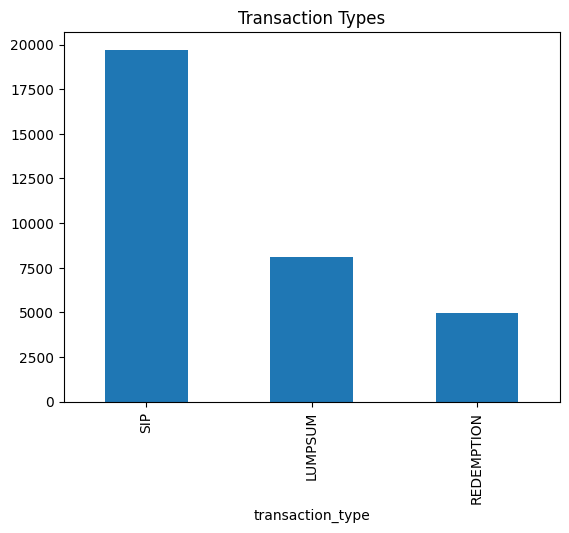

In [6]:
tx["transaction_type"].value_counts().plot(
    kind="bar"
)

plt.title("Transaction Types")
plt.show()

In [9]:
plt.savefig("/workspaces/bluestock_mf_capstone/reports/transaction_types.png")

<Figure size 640x480 with 0 Axes>

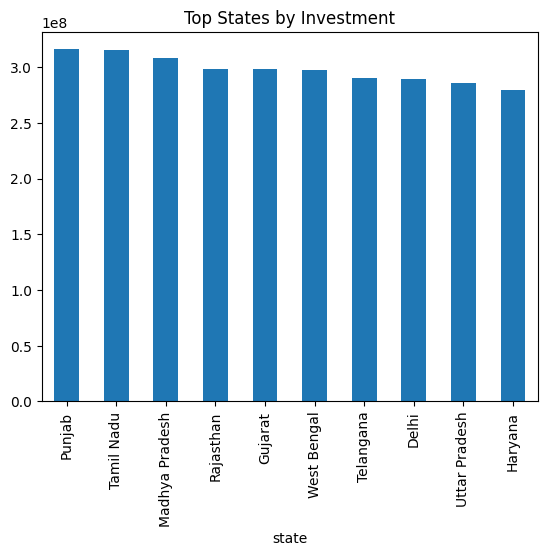

In [10]:
state_amt = tx.groupby("state")["amount_inr"].sum()

state_amt.sort_values(
    ascending=False
).head(10).plot(kind="bar")

plt.title("Top States by Investment")
plt.show()

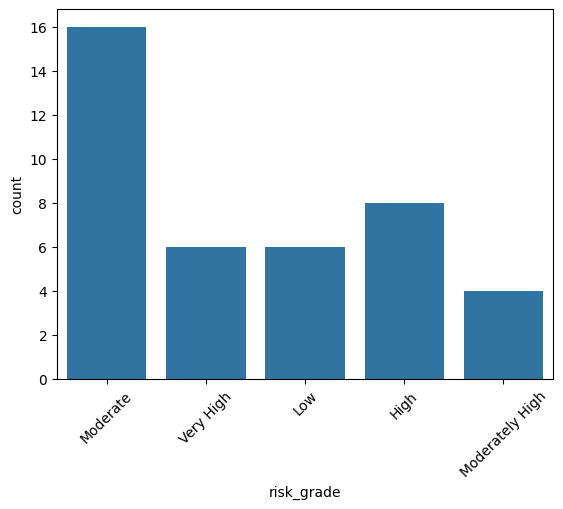

In [11]:
sns.countplot(
    data=perf,
    x="risk_grade"
)

plt.xticks(rotation=45)
plt.show()

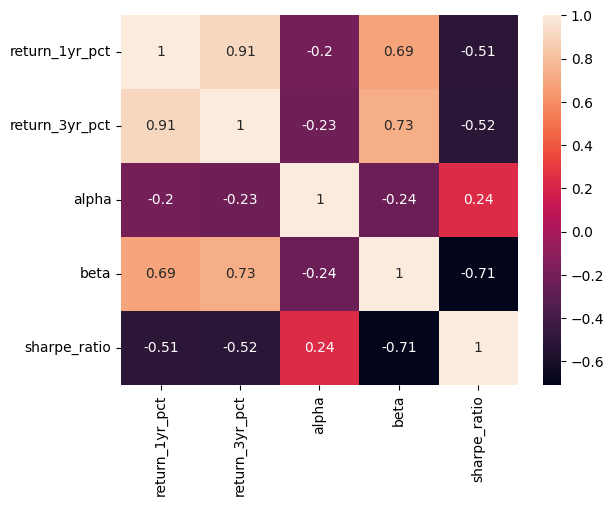

In [12]:
corr = perf[
    [
        "return_1yr_pct",
        "return_3yr_pct",
        "alpha",
        "beta",
        "sharpe_ratio"
    ]
].corr()

sns.heatmap(
    corr,
    annot=True
)

plt.show()